# 01 Data Exploration
**Owner:** Group

This notebook handles exploratory data analysis, missing values, and demographic distributions for the OULAD dataset.


In [ ]:
import sys
from pathlib import Path
# Add the parent directory to sys.path so we can import src
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_oulad, get_feature_columns, encode_categoricals

## 1. Load Data


In [ ]:
df = load_oulad()
print("Data shape:", df.shape)
df.head()

Data shape: (32593, 17)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,vle_days,weighted_score,submission_rate,target
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,40.0,82.4,1.0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,80.0,65.4,1.0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,12.0,NaN,NaN,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,123.0,76.3,1.0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,70.0,55.0,1.0,0


## 2. Target Class Distribution


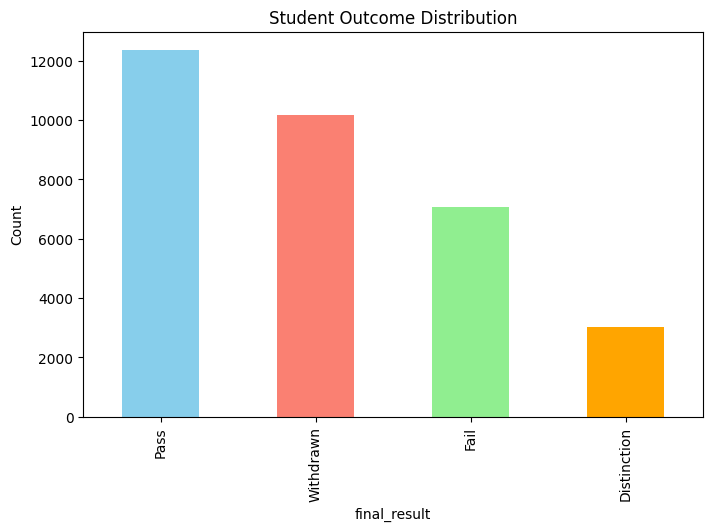

In [3]:
plt.figure(figsize=(8, 5))
df['final_result'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.title('Student Outcome Distribution')
plt.ylabel('Count')
plt.show()

## 3. Missing Value Analysis


In [4]:
missing_info = df.isnull().sum().sort_values(ascending=False)
missing_info[missing_info > 0]

weighted_score     6750
submission_rate    6750
vle_days           3365
total_clicks       3365
imd_band           1111
dtype: int64

In [5]:
# Fill missing values in categorical columns if any
if 'imd_band' in df.columns:
    df['imd_band'] = df['imd_band'].fillna('Unknown')
if 'age_band' in df.columns:
    df['age_band'] = df['age_band'].fillna('Unknown')

## 4. Demographic Distribution (Fairness Baseline)
Checking the target rate (fail/withdrawn) across different demographic groups.


In [6]:
for col in ['gender', 'disability', 'imd_band', 'highest_education']:
    if col in df.columns:
        print(f"\n--- Target rate by {col} ---")
        print(df.groupby(col)['target'].mean().sort_values(ascending=False))


--- Target rate by gender ---
gender
M    0.538126
F    0.515627
Name: target, dtype: float64

--- Target rate by disability ---
disability
Y    0.618521
N    0.518230
Name: target, dtype: float64

--- Target rate by imd_band ---
imd_band
0-10%      0.648445
10-20      0.613766
20-30%     0.592501
40-50%     0.534091
30-40%     0.530941
50-60%     0.512164
70-80%     0.484891
60-70%     0.480895
80-90%     0.459450
90-100%    0.424685
Unknown    0.342934
Name: target, dtype: float64

--- Target rate by highest_education ---
highest_education
No Formal quals                0.703170
Lower Than A Level             0.611491
A Level or Equivalent          0.479672
HE Qualification               0.438266
Post Graduate Qualification    0.345048
Name: target, dtype: float64


## 5. VLE and Assessment Distributions


In [7]:
numeric_features = ['total_clicks', 'vle_days', 'weighted_score', 'submission_rate']
df[numeric_features].describe()

,total_clicks,vle_days,weighted_score,submission_rate
count,29228.000000,29228.000000,25843.000000,25843.000000
mean,1355.039654,61.862563,70.056259,0.997877
std,1733.546045,54.027412,17.309092,0.036028
min,1.000000,1.000000,0.000000,0.000000
25%,260.750000,18.000000,60.115556,1.000000
50%,739.500000,47.000000,72.848000,1.000000
75%,1770.000000,92.000000,82.827134,1.000000
max,24139.000000,286.000000,100.000000,1.000000


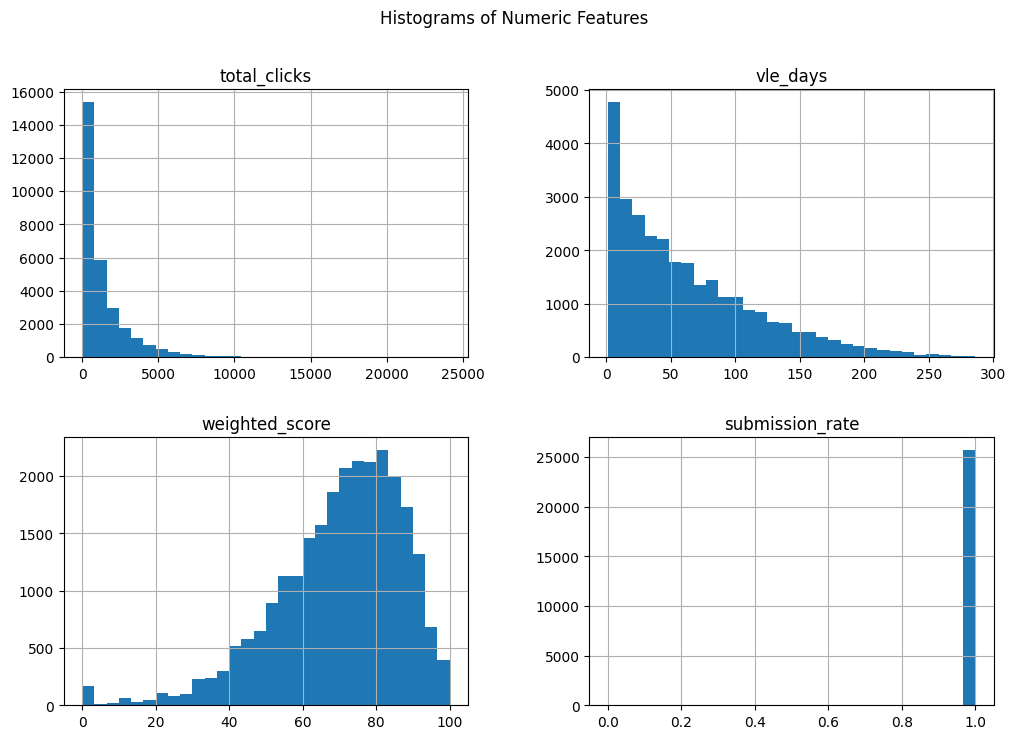

In [8]:
df[numeric_features].hist(bins=30, figsize=(12, 8))
plt.suptitle('Histograms of Numeric Features')
plt.show()

## 6. Correlation Matrix


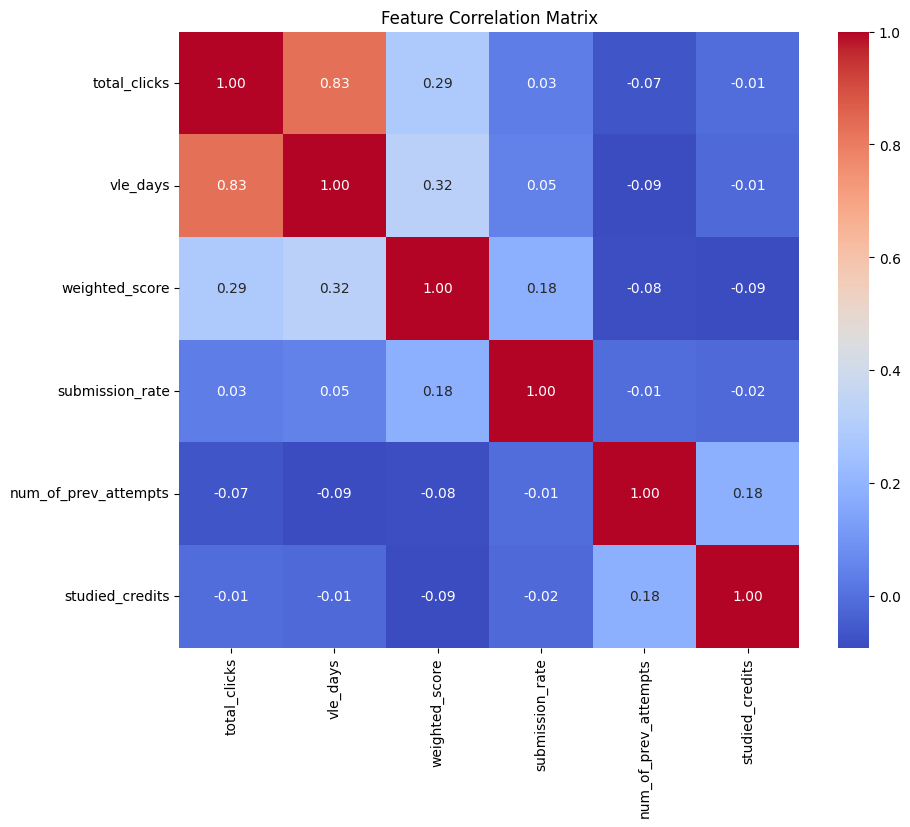

In [9]:
feature_cols, _ = get_feature_columns(df)
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()